# 01 - Analise Exploratoria

Notebook para investigar distribuicoes, valores ausentes, outliers e relacoes iniciais com risco de credito.

In [10]:
import pandas as pd
import numpy as np

# loading data
df = pd.read_csv('../data/raw/application_train.csv')

print('Shape (rows, columns):', df.shape)

df.head()


Shape (rows, columns): (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [18]:
# Data types and null values
print('\n--- data types ---')
print(df.dtypes.value_counts())

print('\n--- Top 10 columns with the most null values ---')
null = df.isnull().sum().sort_values(ascending=False)
print(null[null > 0].head(10))

# Distribution of the target variable
print('\n--- Distribution of the target variable (0=Paid, 1=Delinquent)---')

print((df['TARGET'].value_counts(normalize=True) * 100).round(3)) 


--- data types ---
float64    65
int64      41
object     16
Name: count, dtype: int64

--- Top 10 columns with the most null values ---
COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
COMMONAREA_MEDI             214865
NONLIVINGAPARTMENTS_MEDI    213514
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_AVG     213514
FONDKAPREMONT_MODE          210295
LIVINGAPARTMENTS_AVG        210199
LIVINGAPARTMENTS_MEDI       210199
LIVINGAPARTMENTS_MODE       210199
dtype: int64

--- Distribution of the target variable (0=Paid, 1=Delinquent)---
TARGET
0    91.927
1     8.073
Name: proportion, dtype: float64


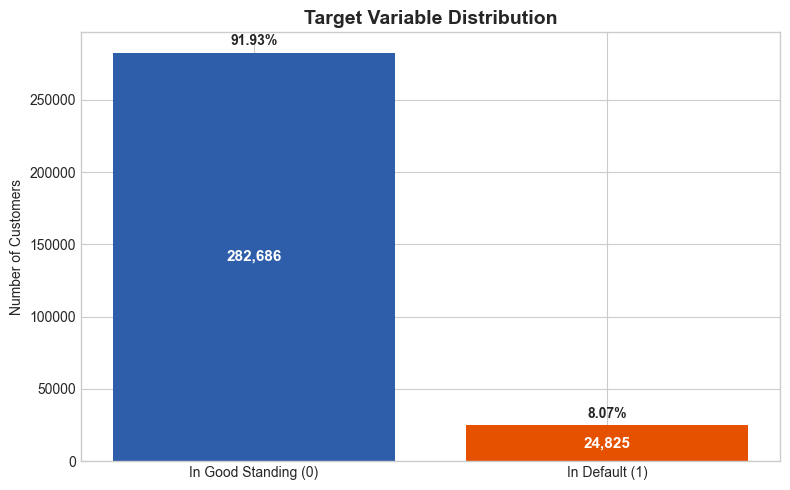

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Default visual style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# TARGET distribution plot
fig, ax = plt.subplots(figsize=(8, 5))
target_counts = df['TARGET'].value_counts()
colors = ['#2E5EAA', '#E65100']

# ensure we pass a NumPy array to matplotlib
counts = target_counts.to_numpy(dtype=float)

bars = ax.bar(['In Good Standing (0)', 'In Default (1)'], counts, color=colors)
ax.set_title('Target Variable Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Customers')

# Add labels: absolute count inside, percentage above
for i, count in enumerate(counts):
    percentage = (count / len(df)) * 100
    
    # absolute count inside the bar
    ax.text(i, count/2, f'{int(count):,}', ha='center', va='center',
            color='white', fontweight='bold', fontsize=11)
    
    # percentage above the bar
    ax.text(i, count + (len(df)*0.01), f'{percentage:.2f}%', ha='center',
            va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('../data/processed/target_distribution.png', dpi=150)
plt.show()
